In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/instacart-market-basket-analysis/departments.csv.zip
/kaggle/input/instacart-market-basket-analysis/sample_submission.csv.zip
/kaggle/input/instacart-market-basket-analysis/order_products__train.csv.zip
/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv.zip
/kaggle/input/instacart-market-basket-analysis/orders.csv.zip
/kaggle/input/instacart-market-basket-analysis/products.csv.zip
/kaggle/input/instacart-market-basket-analysis/aisles.csv.zip


In [2]:
#Standard data science libraries.
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans #for kmeans algorithm

#For dimensionality reduction.
from sklearn.decomposition import PCA #pca from decomposition module.
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition #decomposition module

#Plotting params.
%matplotlib inline
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
rcParams['figure.figsize'] = 12, 4
sb.set_style('whitegrid')

np.random.seed(42) # set the seed to make examples repeatable

In [3]:
#Since the files are zipped, they need to be imported with the following approach. 

prior = "order_products__prior.csv"
order_train = "order_products__train.csv"
orders = "orders.csv"
products = "products.csv"
aisles = "aisles.csv"
departments = "departments.csv"

In [4]:
import zipfile # Unzips the files
from subprocess import check_output    

#Prior Dataset
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+prior+".zip","r") as z:
    z.extractall(".")
prior = pd.read_csv("order_products__prior.csv")

#Order_Train Dataset.
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+order_train+".zip","r") as z:
    z.extractall(".")
order_train = pd.read_csv("order_products__train.csv")

#Orders Dataset.
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+orders+".zip","r") as z:
    z.extractall(".")
orders = pd.read_csv("orders.csv")

#Products
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+products+".zip","r") as z:
    z.extractall(".")
products = pd.read_csv("products.csv")

#Aisles
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+aisles+".zip","r") as z:
    z.extractall(".")
aisles = pd.read_csv("aisles.csv")

#Departments
with zipfile.ZipFile("/kaggle/input/instacart-market-basket-analysis/"+departments+".zip","r") as z:
    z.extractall(".")
departments = pd.read_csv("departments.csv")

# PART 1: Customer Segmentation

The first part revolves around inspecting the data and segmenting customers into clusters using K-Means.

In [5]:
# Inspect all the dataframes, join them and make a combined df to form clusters. 

In [6]:
#Put them in a list to print shape.
combined_df_list = [products,orders, departments, aisles, prior, order_train]

In [7]:
#Check the size of the datasets.
for i in combined_df_list:
    print (i.shape)
#There are two df's which are very large in size, subset to use it on local machine with limited compute power.
del combined_df_list

(49688, 4)
(3421083, 7)
(21, 2)
(134, 2)
(32434489, 4)
(1384617, 4)


In [8]:
#Products Dataframe
products.head(2)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13


In [9]:
#Departments Dataframe
departments.head(2)

,department_id,department
0,1,frozen
1,2,other


In [10]:
#Aisles Dataframe - Products are kept in aisles.
aisles.head(2)

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses


In [11]:
#Orders Dataframe
orders.head(2)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0


In [12]:
#Orders Train Dataframe
order_train.head(2)

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1


In [13]:
#Products in Orders (Prior) - These files specify which products were purchased in each order. Contains Previous Orders.
prior.head(2) #notice the reordered feature.

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1


In [14]:
#Since the dataframe is too big for in memory computation, reducing prior to only 500k rows. 
prior = prior [:500000]

#### Once the df's have been inspected, the next step is to combine them on primary and foreign keys. 

Merge 1 - Combining the orders to prior df. This will give the products that were ordered in each order. 

Merge 2 - Combining the department and aisle df's to product df. 

In [15]:
#Merge 1 - Prior and Orders DF (Joining Orders to prior df)
#Combining the Prior and Orders dataframe - shows which user ordered what products and in which order.
df1 = pd.merge(prior, orders, on= 'order_id')
df1.head(2)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,prior,3,5,9,8.0
1,2,28985,2,1,202279,prior,3,5,9,8.0


In [16]:
#Merge 2
#Combining the department and aisle df's to product df. 
prod_aisles = pd.merge(products, aisles, on = 'aisle_id')
df2 = pd.merge(prod_aisles, departments, on = 'department_id')
df2.head(2)

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,78,Nutter Butter Cookie Bites Go-Pak,61,19,cookies cakes,snacks


In [17]:
#Combining df1 anf df2
combined_df = pd.merge(df1, df2, on = 'product_id').reset_index(drop=True)
combined_df.head(2)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,26,33120,5,0,153404,prior,2,0,16,7.0,Organic Egg Whites,86,16,eggs,dairy eggs


# Data Exploration - Mini Version

A lot more will be covered on this in the subsequent commits.

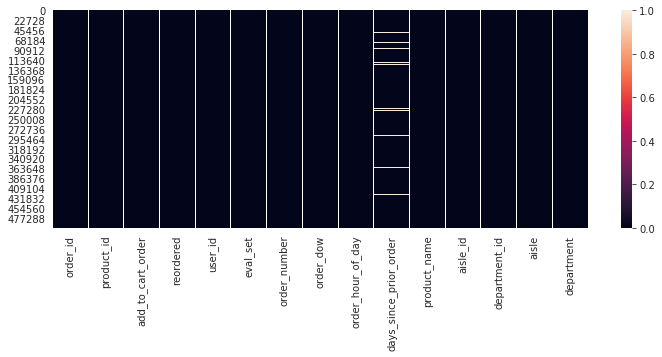

In [18]:
#Check Nulls
sb.heatmap(combined_df.isnull(), cbar=True)

In [19]:
#These are null values in the feature 'days_since_prior_order'
combined_df[combined_df['days_since_prior_order'].isnull()].head(2)

#To be dealt with later, as this does not influence the current scope of work.

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
39,5733,33120,8,0,92179,prior,1,6,10,NaN,Organic Egg Whites,86,16,eggs,dairy eggs
53,8762,33120,4,0,68183,prior,1,3,8,NaN,Organic Egg Whites,86,16,eggs,dairy eggs


In [20]:
#Most ordering customer. Favourite Customer?
pd.DataFrame(combined_df.groupby('user_id')['product_id'].count()).sort_values('product_id', ascending=False).head(2)

#User_id = 142131

,product_id
user_id,
142131,176
169550,161


In [21]:
#Most ordered items.
pd.DataFrame(combined_df['product_name'].value_counts()).head(5)

,product_name
Banana,7365
Bag of Organic Bananas,5920
Organic Strawberries,4023
Organic Baby Spinach,3797
Organic Hass Avocado,3317


In [22]:
#Most sold items as per aisle.
pd.DataFrame(combined_df['aisle'].value_counts()).head(5)

,aisle
fresh fruits,56326
fresh vegetables,52073
packaged vegetables fruits,27347
yogurt,22485
packaged cheese,14960


# Data Modeling

## Preparing Data 

In [23]:
combined_df.shape

(500000, 15)

In [24]:
#Using aisles and user_id. This shows the users that purchased items from which aisle.
user_by_aisle_df = pd.crosstab(combined_df['user_id'], combined_df['aisle'])
user_by_aisle_df.head(2)

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [25]:
#The final dataframe has about 134 features.
user_by_aisle_df.shape

(39834, 134)

In [26]:
#Standardization is not needed in this case.
user_by_aisle_df.describe() #this confirms that the values dont need to be standardized since they're all 'quantity'.

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
count,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,...,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000,39834.000000
mean,0.007004,0.067355,0.003113,0.002887,0.149746,0.013632,0.121454,0.008410,0.002109,0.019406,...,0.113320,0.098986,0.051213,0.072526,0.013782,0.013305,0.018000,0.320781,0.011322,0.564468
std,0.102322,0.322399,0.059625,0.057711,0.914706,0.125322,0.458353,0.111384,0.050060,0.248107,...,0.392178,0.517674,0.294278,0.295638,0.131369,0.124048,0.154928,0.801316,0.130455,1.314491
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,6.000000,9.000000,4.000000,3.000000,36.000000,3.000000,9.000000,7.000000,2.000000,11.000000,...,7.000000,22.000000,9.000000,6.000000,6.000000,3.000000,6.000000,20.000000,4.000000,47.000000


## Dimensionality Reduction using Elbow Method and PCA 

Since there are 134 features, they need to be lowered to a lower dimension with only the most important features.

PCA will be implemented using elbow method to compute the ideal value of 'k' clusters.

PCA is most common form of SVD (Singular Value Decomposition), SVD essentially decomposes the matrix into other resultant matrices to reduce information redundancy and noise. In the case above, the idea is to reduce the number of features from 134 to only the most relevant ones that capture the essence of the data.

#### But how to choose the number of principal components for PCA?

Elbow Method or K-Means

Important Note: The data does not need to be standardized since all the items bought by the user is quantity of units bought. 

### Using Elbow Method 

The bend of the elbow is where the ideal value of k lies.

In [27]:
#Taking array of 'user_by_aisle_df'. To use for elbow method.
X = user_by_aisle_df.values

In [28]:
user_by_aisle_df.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
23,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,4
27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,4
36,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


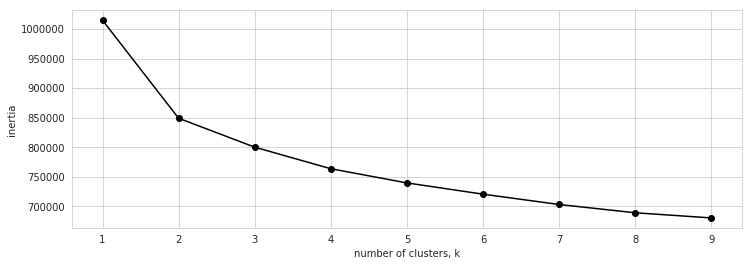

In [29]:
#Implementing the Elbow method to identify the ideal value of 'k'. 

ks = range(1,10) #hit and trial, let's try it 10 times.
inertias = []
for k in ks:
    model = KMeans(n_clusters=k)    # Create a KMeans instance with k clusters: model
    model.fit(X)                    # Fit model to samples
    inertias.append(model.inertia_) # Append the inertia to the list of inertias
    
plt.plot(ks, inertias, '-o', color='black') #Plotting. The plot will give the 'elbow'.
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

### Using PCA 

The data has been reduced to just 6 components, which explain about 50% variation in the data.

In [30]:
#Seeing the above plot, the ideal value for cluster (k) should be between 5 and 6 - since the features beyond these values,
# do not explain much of the variability in the dataset. 

#Decomposing the features into 6 using PCA (seeing the above plot, n_components = 6)
pca = decomposition.PCA(n_components=6)
pca_user_order = pca.fit_transform(X)

#You can do hit and trial here to change the number of components and see how much variation in the data 
#is explained by the chose n_components.

In [31]:
#Checking the % variation explained by the 6 pca components.
pca.explained_variance_ratio_.sum()
#More than half (50%) of the variability in the data can be explained by just 6 components.

0.5179968590169132

Text(0, 0.5, 'variance %')

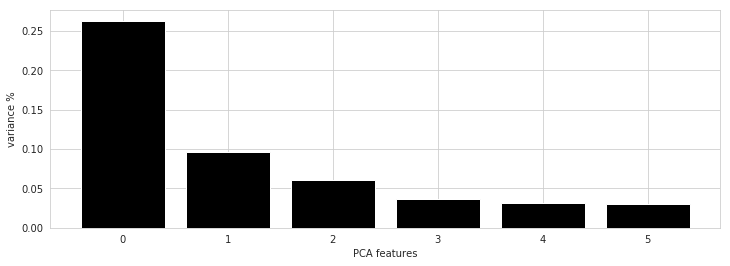

In [32]:
# Plot the explained variances to verify the variation.
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')

#A majority of the variance can be explained by just five to six components. Anything beyond that does not capture much of the variation in the dataset.

### Build The Model - K Means

Once the dimensionality has been lowered, the model can be built with the most chosen paramters.

In [33]:
#Chosen components.
PCA_components = pd.DataFrame(pca_user_order)
PCA_components.head(5)

,0,1,2,3,4,5
0,-0.434904,0.964055,-1.085496,-0.804474,-0.461815,-1.122796
1,-2.163437,-0.472227,-0.130003,0.238154,0.045857,-0.175909
2,-1.316257,1.287541,3.167225,0.659952,-0.599932,-1.081585
3,-1.588246,1.262179,3.217635,1.250327,-0.408643,-0.299673
4,-2.262804,-0.397136,-0.112547,0.290019,-0.004209,-0.063501


In [34]:
#Build the model (kmeans using 5 clusters)
kmeans = KMeans(n_clusters=5)
X_clustered = kmeans.fit_predict(pca_user_order) #fit_predict on chosen components only.

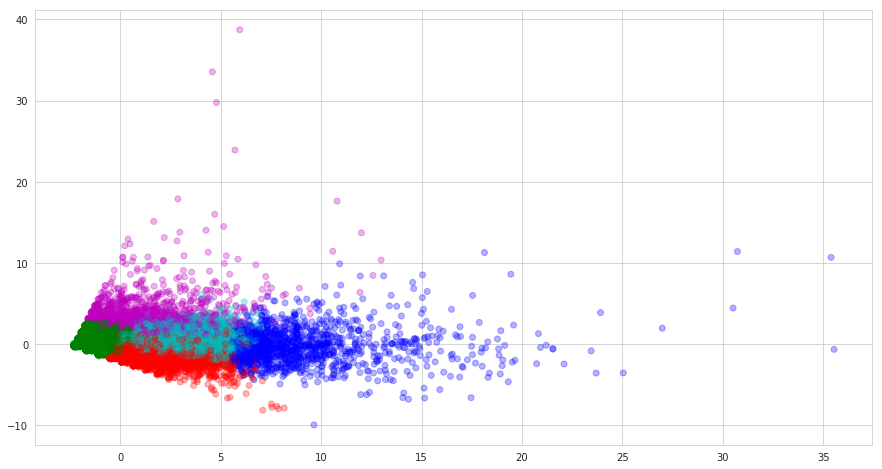

In [35]:
#Visualize it.

label_color_mapping = {0:'r', 1: 'g', 2: 'b',3:'c' , 4:'m'}
label_color = [label_color_mapping[l] for l in X_clustered]

#Scatterplot showing the cluster to which each user_id belongs.
plt.figure(figsize = (15,8))
plt.scatter(pca_user_order[:,0],pca_user_order[:,2], c= label_color, alpha=0.3) 
plt.xlabel = 'X-Values'
plt.ylabel = 'Y-Values'
plt.show()

In [36]:
#This contains all the clusters which are to be mapped to each user_id in the user_by_aisle_df.
X_clustered.shape

(39834,)

In [37]:
#Mapping clusters to users.
user_by_aisle_df['cluster']=X_clustered

In [38]:
#Checking cluster concentration. 
user_by_aisle_df['cluster'].value_counts().sort_values(ascending = False)

1    25238
0     6418
3     5187
4     1660
2     1331
Name: cluster, dtype: int64

In [39]:
#Check out cluster mapping.
user_by_aisle_df.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
13,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
23,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,4,4
27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,4,4
36,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


# PART 2: Association Rules

In [40]:
# Apriori Algorithm - Association Rules

#Some Theory - just a little.

#Fomatting Data
#Applying Apriori to get support in order to see what items go well together.
#Applying Association Rules to get the Confidence and Lift Scores
#How to come up with up-selling and cross-selling stratgies. The END.

Assumptions/Caveats

Transaction Data has to be in sparse format apriori algorithm.

* Fast
* Works well with less data
* Few (if any) feature engineering requirement 

Its a process that deploys pattern recognition to identify and quantify relationships between different yet related items.
Action 1: Place eggs and bread together so the customer does not need to walk, to get the items.
Action 2: Advertise eggs to bread buyer so they buy both together. Once you know the products are related.


Ex: 5000 total transactions, 500 were bread purchases, 350 eggs, and 150 both eggs and bread.

Measure Association

*  Support: Relative freq of item within a transaction dataset. Support for bread is (500/5000) = 0.1

*  Confidence: What is the confidence that eggs (item2) will be bought if bread (item1) was purchased. EX: (150/5000)/(500/5000) = 30%. There is a 30% chance that eggs will be bought when bread is bought.
 
*  Lift: A value that shows the relationship between two items. It is the confidence A->C/support(C)
 
    * If lift > 1: A is highly associated with C (Eggs will be bought if Bread, item 'A' was bought)
    * If lift < 1: If A was purchased, it is unlikely C will be purchased too.
    * If lift = 1: No association betweem item A and C.

Lift = 0.3/(350/5000) = 4.28

In [41]:
#Importing Libraries
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [42]:
#Checking with only a few samples. Concept is replicable.
np.random.seed(942) # set the seed to make examples repeatable
df2 = combined_df.sample(n=1000)[['user_id','product_name']]
basket = pd.crosstab(df2['user_id'],df2['product_name']).astype('bool').astype('int')
del df2

In [43]:
#Checking and removing index.
basket=basket.reset_index(drop=True)
basket.index

RangeIndex(start=0, stop=980, step=1)

In [44]:
#Lets see if the format is correct.
basket.head(2)

product_name,0% Fat Greek Yogurt Vanilla,0% Greek Strained Yogurt,1% Low Fat Milk,100 Calorie Bartlett in Extra Light Syrup Pear Halves,100% Apple Juice,100% Apple Juice Boxes,100% Grass-Fed Organic Plain Creamline Yogurt,100% Pure Organic Apple Juice,100% Raw Coconut Water,100% Recycled 2 Ply Paper Towels,...,Yellow Grape Tomatoes,Yellow Onions,Yellow Potato,Yo Baby Organic Vanilla Yogurt,YoBaby Blueberry Apple Yogurt,YoKids Squeeze Organic Blueberry Blue Yogurt,Yoghurt Blueberry,Zen Tea,Zero Calorie Cola,Zero Calorie Cream Soda
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
#Calling apriori algorithm on dummified data - basket.
frequent_itemsets=apriori(basket, min_support=0.00002, use_colnames=True).sort_values('support', ascending=False) 

#These are all the POPULAR (Top 20) items purchased from the store.
frequent_itemsets.head(20)

,support,itemsets
48,0.013265,(Bag of Organic Bananas)
50,0.009184,(Banana)
455,0.009184,(Organic Hass Avocado)
555,0.007143,(Organic Whole Milk)
530,0.007143,(Organic Strawberries)
562,0.006122,(Organic Yellow Onion)
385,0.006122,(Organic Baby Spinach)
294,0.006122,(Large Lemon)
302,0.006122,(Limes)
378,0.006122,(Organic Avocado)


In [46]:
#Lets check the length of the item sets using a tini lambda function.
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets.head()

,support,itemsets,length
48,0.013265,(Bag of Organic Bananas),1
50,0.009184,(Banana),1
455,0.009184,(Organic Hass Avocado),1
555,0.007143,(Organic Whole Milk),1
530,0.007143,(Organic Strawberries),1


In [47]:
#Putting a new filter to get all items with length 3 or more. (this means items purchased together)
frequent_itemsets[frequent_itemsets['length'] >= 3]

,support,itemsets,length
814,0.00102,"(Banana, Organic Baby Spinach, Bunched Cilantro)",3
815,0.00102,"(Diced Tomatoes, Honey Turkey Breast, Organic ...",3


ASSOCIATION RULES

* First Part - Confidence
* Second Part - Lift
* Third Part - Confidence + Lift

In [48]:
#FIRST PART - CONFIDENCE

#For association rules, metric can be either confidence or lift. Second argument is minimum threshold (0.5).
#Trying confidence first.
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules.head()

#The minimum confidence level starts at 0.5 (confidence column). How likely is it for item C to be purchased if A was purchased?
#Hence if 'Kidz All Natural Baked Chicken Nuggets' was purchased, it is extremely likely that 'Quart Sized Easy Open Freezer Bags' will be purchased in the same transaction. 
#Confidence tells us if item C is purchased, how likely will item A be purchased too.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Kidz All Natural Baked Chicken Nuggets),(Quart Sized Easy Open Freezer Bags),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf
1,(Quart Sized Easy Open Freezer Bags),(Kidz All Natural Baked Chicken Nuggets),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf
2,(Honey Turkey Breast),(Organic Tomato Cluster),0.002041,0.001020,0.00102,0.5,490.0,0.001018,1.997959
3,(Organic Tomato Cluster),(Honey Turkey Breast),0.001020,0.002041,0.00102,1.0,490.0,0.001018,inf
4,(French Beans),(Organic Roasted Turkey Breast),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf


In [49]:
#SECOND PART - LIFT

#Changing metric to lift. Minimum threshold is 1.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.head()

#Lift tells how likely are items bought together as opposed to being bought individually.
#Row 0: If Kidz All Natural Baked Chicken Nuggets is purchased, then Quart Sized Easy Open Freezer Bags will be purchased too.
#Row 1: If Quart Sized Easy Open Freezer Bags item is purchased, then Kidz All Natural Baked Chicken Nuggets will be purchased. As there is SLIGHTLY more confidence in row1 (compared to row0).


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Kidz All Natural Baked Chicken Nuggets),(Quart Sized Easy Open Freezer Bags),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf
1,(Quart Sized Easy Open Freezer Bags),(Kidz All Natural Baked Chicken Nuggets),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf
2,(Honey Turkey Breast),(Organic Tomato Cluster),0.002041,0.001020,0.00102,0.5,490.0,0.001018,1.997959
3,(Organic Tomato Cluster),(Honey Turkey Breast),0.001020,0.002041,0.00102,1.0,490.0,0.001018,inf
4,(French Beans),(Organic Roasted Turkey Breast),0.001020,0.001020,0.00102,1.0,980.0,0.001019,inf


In [50]:
#THIRD PART - CONFIDENCE AND LIFT

#Select life>5 and confidence >.5
rules[(rules['lift'] >= 5) & (rules['confidence']>= 0.5)] 

#Now these items will be mostly be bought together. So you can make Cross-sell/upsell strategies based on that.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Kidz All Natural Baked Chicken Nuggets),(Quart Sized Easy Open Freezer Bags),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
1,(Quart Sized Easy Open Freezer Bags),(Kidz All Natural Baked Chicken Nuggets),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
2,(Honey Turkey Breast),(Organic Tomato Cluster),0.002041,0.001020,0.00102,0.5,490.000000,0.001018,1.997959
3,(Organic Tomato Cluster),(Honey Turkey Breast),0.001020,0.002041,0.00102,1.0,490.000000,0.001018,inf
4,(French Beans),(Organic Roasted Turkey Breast),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
5,(Organic Roasted Turkey Breast),(French Beans),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
6,(Gourmet All Purpose Medium Cinnamon Hazelnut ...,(Fire Roasted Diced Green Mild Chiles),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
7,(Fire Roasted Diced Green Mild Chiles),(Gourmet All Purpose Medium Cinnamon Hazelnut ...,0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
8,(Organic Sweet & Salty Peanut Pretzel Granola...,(Organic Romaine),0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf
9,(Organic Romaine),(Organic Sweet & Salty Peanut Pretzel Granola...,0.001020,0.001020,0.00102,1.0,980.000000,0.001019,inf


In [51]:
#Next steps - Some tuning to improve performance. 